In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path('../python_code').resolve()))
import numpy as np
import cv2
import csv
from scipy.stats import rankdata
import torch
from torch import nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
%matplotlib inline
from DataGenerator import HyperspectralTorchDataset
from SpectralSpatialAttentionModel import SpectralSpatialMultiHeatmapAttentionModel

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

image_path = Path("../home/ARO.local/collaboration/sagi-tomer-collab/Normalized_Tomato_Seeds/Infected/Tray_2_row_0_column_12.npy")
model_path = Path("../home/ARO.local/collaboration/sagi-tomer-collab/Normalized_Tomato_Seeds/Models/SpectralSpatialMultiHeatmapAttentionModel_1-92-183-274-365-456-547-638-bands-0.975-accuracy.pt")
seeds_root = Path("../home/ARO.local/collaboration/sagi-tomer-collab/Normalized_Tomato_Seeds")

# --- Infer Bands and Label ---
model_name = model_path.stem
bands_str = model_name.split("_")[1].split("-bands")[0]
bands = list(map(int, bands_str.split("-")))
label = 0 if "Healthy" in str(image_path) else 1
print(bands, label)

# --- Prepare Image ---
image = np.load(image_path)
height, width = image.shape[:2]
shape = (height, width, len(bands))

dataset = HyperspectralTorchDataset([str(image_path)], [label], bands, shape)
loader = DataLoader(dataset, batch_size=1, shuffle=False)

for image, _ in loader:
    image = image.to(device)

[1, 92, 183, 274, 365, 456, 547, 638] 1


c:\Users\sagig\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\cuda\__init__.py:905: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11010). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\c10\cuda\CUDAFunctions.cpp:108.)
  r = torch._C._cuda_getDeviceCount() if nvml_count < 0 else nvml_count


In [ ]:
attention_model = SpectralSpatialMultiHeatmapAttentionModel(len(bands))

# Load the state dict
state = torch.load(model_path, map_location=device)

# Strip the prefix, if needed (for example, '_orig_mod.')
state = {k.replace("_orig_mod.", ""): v for k, v in state.items()}

# Get current model state_dict
model_state = attention_model.state_dict()

# Update only the matching keys
for key in model_state.keys():
    if key in state and state[key].shape == model_state[key].shape:
        model_state[key] = state[key]  # Copy the matching weights

# Load the state_dict into the model
attention_model.load_state_dict(model_state)

# Now the model is partially loaded with compatible weights
# model = torch.compile(model, backend="eager")
attention_model.to(device).eval()

logits, spec_w, spat_map, fusion_w = attention_model(image)

In [13]:
def generate_input_channel_attributions_with_spectral_grad(model, x):
    """
    Generate spatial attributions (heatmaps) and spectral attention gradients for each input channel.

    Returns:
        heatmaps: List of 2D numpy arrays, one per channel.
        spectral_importances: 1D numpy array of spectral attention gradients (same length as number of bands).
    """
    model.eval()
    x = x.clone().detach().requires_grad_(True)

    # Forward pass
    logits, spec_w, *_ = model(x)
    model.zero_grad()

    # Retain gradient for spec_w (non-leaf tensor)
    spec_w.retain_grad()

    # Use a scalar output to allow gradients to flow
    loss = torch.sigmoid(logits).mean()
    loss.backward()

    # Spatial heatmaps
    grads = x.grad.data
    attributions = x * grads

    heatmaps = []
    for i in range(attributions.shape[1]):
        heatmap = attributions[0, i].detach().cpu().numpy()
        heatmap = np.maximum(heatmap, 0)
        heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
        heatmaps.append(heatmap)

    # Spectral attention importance via spec_w.grad
    if spec_w.grad is None:
        raise RuntimeError("Gradient of spectral attention weights is None. Make sure spec_w requires grad and loss.backward() was called.")

    spectral_importances = spec_w.grad.detach().cpu().numpy().squeeze()

    return heatmaps, spectral_importances

In [15]:
print(spectral_gradients)

[-0.01431308 -0.00775089 -0.01473222 -0.00552989 -0.00635347  0.00147981
  0.01380117  0.01172009]


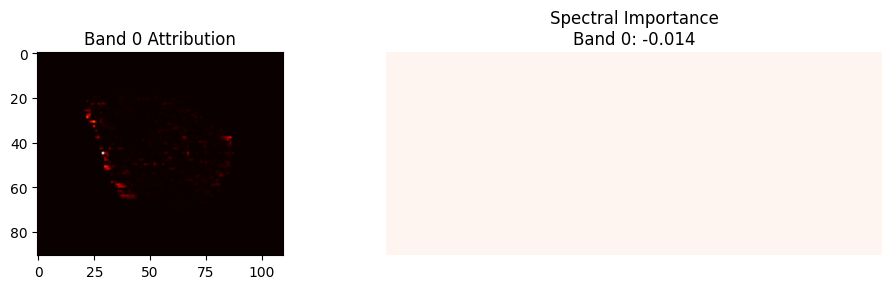

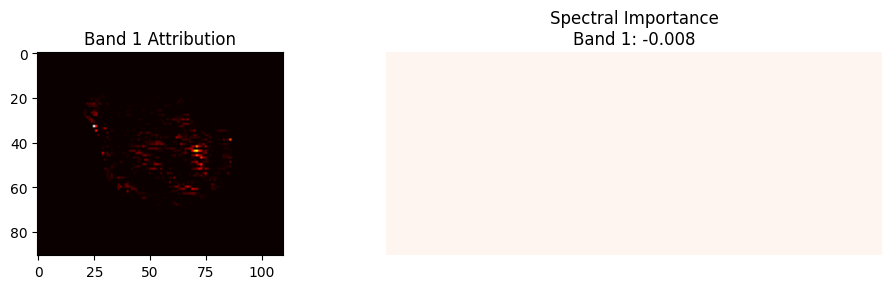

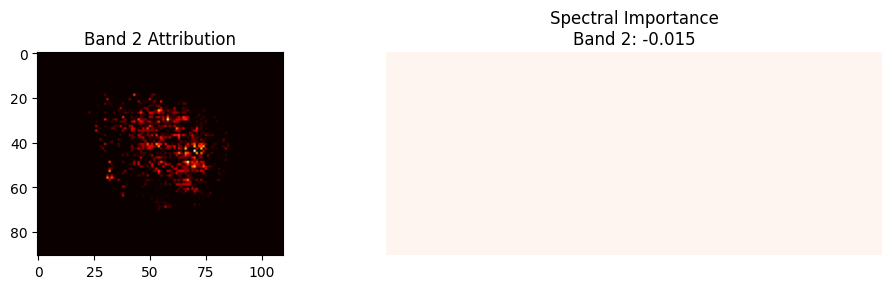

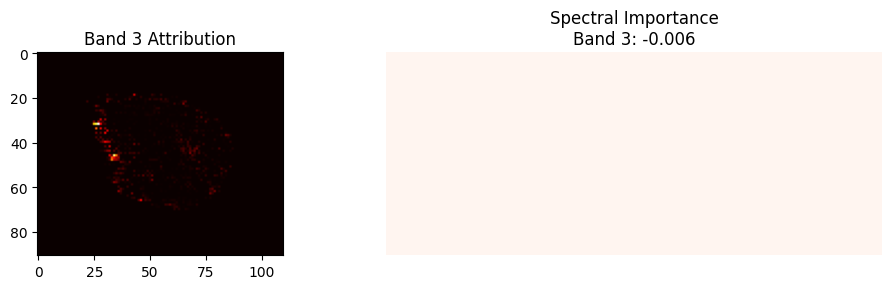

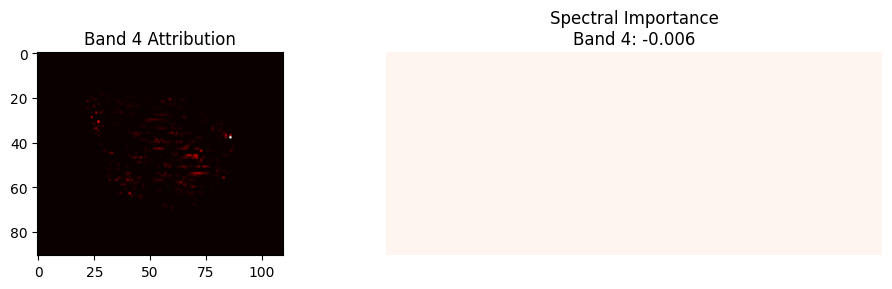

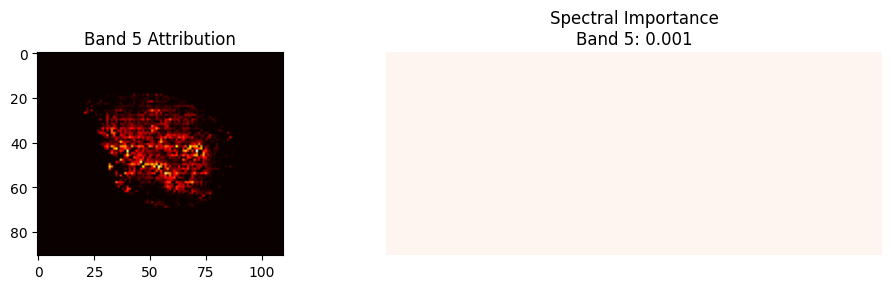

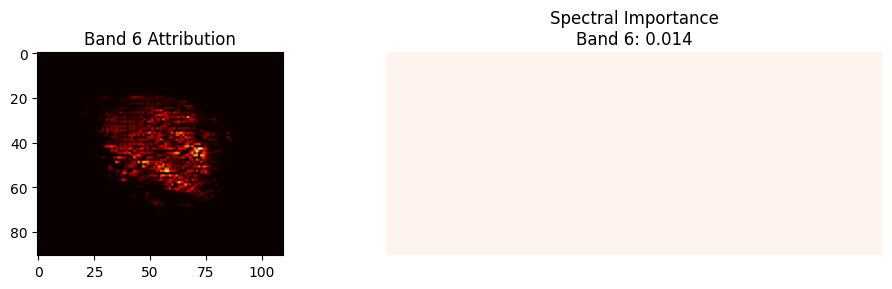

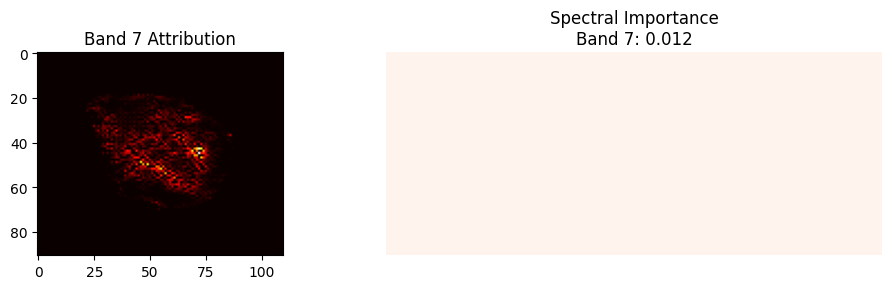

In [14]:
heatmaps, spectral_gradients = generate_input_channel_attributions_with_spectral_grad(attention_model, image)

for i, heatmap in enumerate(heatmaps):
    plt.figure(figsize=(10, 3))

    # Spatial attribution heatmap
    plt.subplot(1, 2, 1)
    plt.imshow(heatmap, cmap='hot')
    plt.title(f'Band {i} Attribution')

    # Spectral importance bar (single value as image)
    plt.subplot(1, 2, 2)
    importance = spectral_gradients[i] if i < len(spectral_gradients) else 0
    plt.imshow([[importance]], cmap='Reds', vmin=0, vmax=1, aspect='auto')
    plt.title(f'Spectral Importance\nBand {i}: {importance:.3f}')
    plt.axis('off')

    plt.tight_layout()
    plt.show()